# Tree-Based Survival Models
Comprehensive Notebook

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
import xgboost as xgb
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay
import joblib

## 2. Load Raw Data

In [5]:
acs = pd.read_csv('ACS_merged_for_measles.csv')
vacc_child = pd.read_csv('Vaccination Coverage Up to 24 Months.csv')
vacc_k = pd.read_csv('Vaccination Coverage And Exemptions Among Kindergartners.csv')
vacc_teen = pd.read_csv('Vaccination Coverage Adolescents.csv')
travel = pd.read_csv('import_data_processed.csv')
trends = pd.read_csv('multiTimeline.csv')
geomap = pd.read_csv('geoMap.csv')
cases = pd.read_csv('measles_county_all_updates.csv')
acs.head()

,GEO_ID,NAME,DP02_0001E,DP02_0001M,DP02_0002E,DP02_0002M,DP02_0003E,DP02_0003M,DP02_0004E,DP02_0004M,...,DP05_0091PE,DP05_0091PM,DP05_0092PE,DP05_0092PM,DP05_0093PE,DP05_0093PM,DP05_0094PE,DP05_0094PM,Unnamed: 378,pct_married_households
0,0500000US01001,"Autauga County, Alabama",22523.0,431.0,11861.0,633.0,5155.0,381.0,1055.0,306.0,...,NaN,NaN,44761,NaN,47.8,0.4,52.2,0.4,NaN,52.661724
1,0500000US01003,"Baldwin County, Alabama",94642.0,1316.0,53118.0,1615.0,16692.0,1043.0,4594.0,588.0,...,NaN,NaN,184665,NaN,48.1,0.1,51.9,0.1,NaN,56.125188
2,0500000US01005,"Barbour County, Alabama",9080.0,315.0,3572.0,287.0,962.0,173.0,361.0,146.0,...,NaN,NaN,19201,NaN,53.3,0.3,46.7,0.3,NaN,39.339207
3,0500000US01007,"Bibb County, Alabama",7571.0,288.0,3971.0,359.0,1187.0,238.0,309.0,120.0,...,NaN,NaN,17469,NaN,53.5,0.6,46.5,0.6,NaN,52.450139
4,0500000US01009,"Blount County, Alabama",21977.0,403.0,12090.0,555.0,4405.0,408.0,1181.0,305.0,...,NaN,NaN,43866,NaN,49.5,0.3,50.5,0.3,NaN,55.012058


## 3. Prepare FIPS Keys

In [7]:
for df in [acs, vacc_child, vacc_k, vacc_teen, travel, trends, geomap, cases]:
    if 'FIPS' in df.columns:
        df['FIPS'] = df['FIPS'].astype(str).str.zfill(5)


## 4. Build Survival Labels

In [9]:
acs['FIPS'] = acs['GEO_ID'].str[-5:]

cases['date'] = pd.to_datetime(cases['date'])
baseline = pd.to_datetime('2024-01-01')

first_cases = (
    cases.groupby('location_id')['date']
         .min()
         .reset_index()
         .rename(columns={'date': 'first_case'})
)

first_cases['event'] = 1
first_cases['time_to_outbreak'] = (first_cases['first_case'] - baseline).dt.days / 30
first_cases['FIPS'] = first_cases['location_id'].astype(str).str.zfill(5)

surv = acs[['FIPS']].drop_duplicates()
surv = surv.merge(first_cases[['FIPS','first_case','event','time_to_outbreak']], on='FIPS', how='left')

surv['event'] = surv['event'].fillna(0)
surv['time_to_outbreak'] = surv['time_to_outbreak'].fillna(
    (pd.to_datetime('2025-01-01') - baseline).days / 30
)

surv.head()

,FIPS,first_case,event,time_to_outbreak
0,01001,NaT,0.0,12.2
1,01003,NaT,0.0,12.2
2,01005,NaT,0.0,12.2
3,01007,NaT,0.0,12.2
4,01009,NaT,0.0,12.2


## 5. Merge Predictors

In [11]:
acs['FIPS'] = acs['GEO_ID'].str[-5:]
acs['STATE'] = acs['NAME'].str.split(', ').str[-1]

vacc_state = vacc_k[vacc_k['GeoType']=='State'][['Geography','Estimate','Exemptions']]
vacc_state = vacc_state.rename(columns={'Geography':'STATE','Estimate':'VaccRate_K','Exemptions':'Exempt_K'})

acs = acs.merge(vacc_state, on='STATE', how='left')

df = surv.merge(acs, on='FIPS', how='left')

df.head()

,FIPS,first_case,event,time_to_outbreak,GEO_ID,NAME,DP02_0001E,DP02_0001M,DP02_0002E,DP02_0002M,...,DP05_0092PM,DP05_0093PE,DP05_0093PM,DP05_0094PE,DP05_0094PM,Unnamed: 378,pct_married_households,STATE,VaccRate_K,Exempt_K
0,01001,NaT,0.0,12.2,0500000US01001,"Autauga County, Alabama",22523.0,431.0,11861.0,633.0,...,NaN,47.8,0.4,52.2,0.4,NaN,52.661724,Alabama,NaN,NaN
1,01003,NaT,0.0,12.2,0500000US01003,"Baldwin County, Alabama",94642.0,1316.0,53118.0,1615.0,...,NaN,48.1,0.1,51.9,0.1,NaN,56.125188,Alabama,NaN,NaN
2,01005,NaT,0.0,12.2,0500000US01005,"Barbour County, Alabama",9080.0,315.0,3572.0,287.0,...,NaN,53.3,0.3,46.7,0.3,NaN,39.339207,Alabama,NaN,NaN
3,01007,NaT,0.0,12.2,0500000US01007,"Bibb County, Alabama",7571.0,288.0,3971.0,359.0,...,NaN,53.5,0.6,46.5,0.6,NaN,52.450139,Alabama,NaN,NaN
4,01009,NaT,0.0,12.2,0500000US01009,"Blount County, Alabama",21977.0,403.0,12090.0,555.0,...,NaN,49.5,0.3,50.5,0.3,NaN,55.012058,Alabama,NaN,NaN


## 6. Prepare Matrices

In [13]:
predictors = [c for c in df.columns if c not in ['FIPS','event','time_to_outbreak','first_case']]
X = df[predictors].fillna(0)
y = Surv.from_dataframe('event','time_to_outbreak',df)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


## 7. Random Survival Forest

In [23]:
df_model = df.drop(columns=['GEO_ID','NAME','STATE','FIPS','first_case'])

X = df_model.drop(columns=['event','time_to_outbreak'])

X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)

X = X.astype(np.float32)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
rsf = RandomSurvivalForest(
    n_estimators=500,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rsf.fit(X_train, y_train)

,n_estimators,500
,max_depth,None
,min_samples_split,6
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


## 8. Cox Model

In [29]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="survival:cox",
    eval_metric="cox-nloglik",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4
)

xgb.fit(X_train, y_train['time_to_outbreak'])

pred_xgb = xgb.predict(X_test)

cindex_xgb = concordance_index_censored(
    y_test['event'],
    y_test['time_to_outbreak'],
    pred_xgb
)[0]

cindex_xgb

0.4783118405627198

## 9. Feature Importance 

<Figure size 800x600 with 0 Axes>

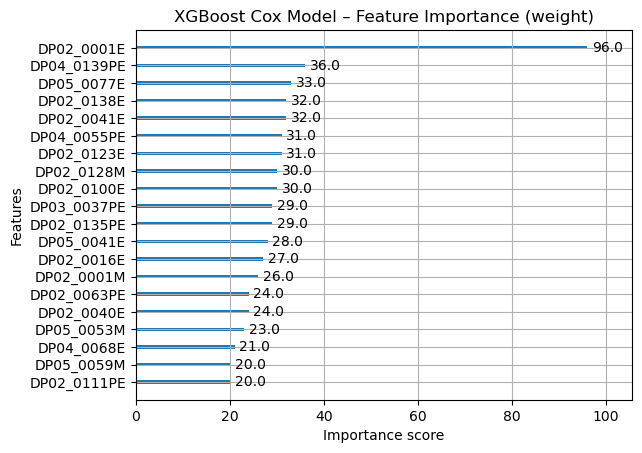

In [31]:
from xgboost import plot_importance

booster = xgb.get_booster()
importance = booster.get_score(importance_type='weight')

if len(importance) == 0:
    print("No built-in feature importance available for Cox trees.")
    print("Using SHAP importance instead.\n")
else:
    plt.figure(figsize=(8,6))
    plot_importance(booster, importance_type='weight', max_num_features=20)
    plt.title("XGBoost Cox Model – Feature Importance (weight)")
    plt.show()

## 10. SHAP Global Importance

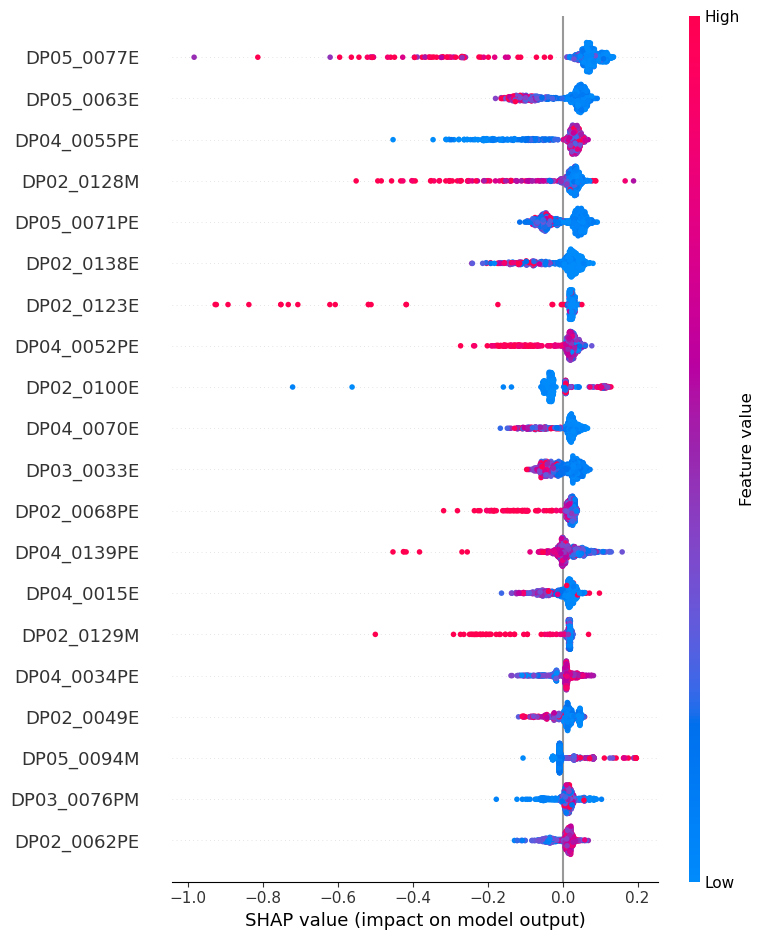

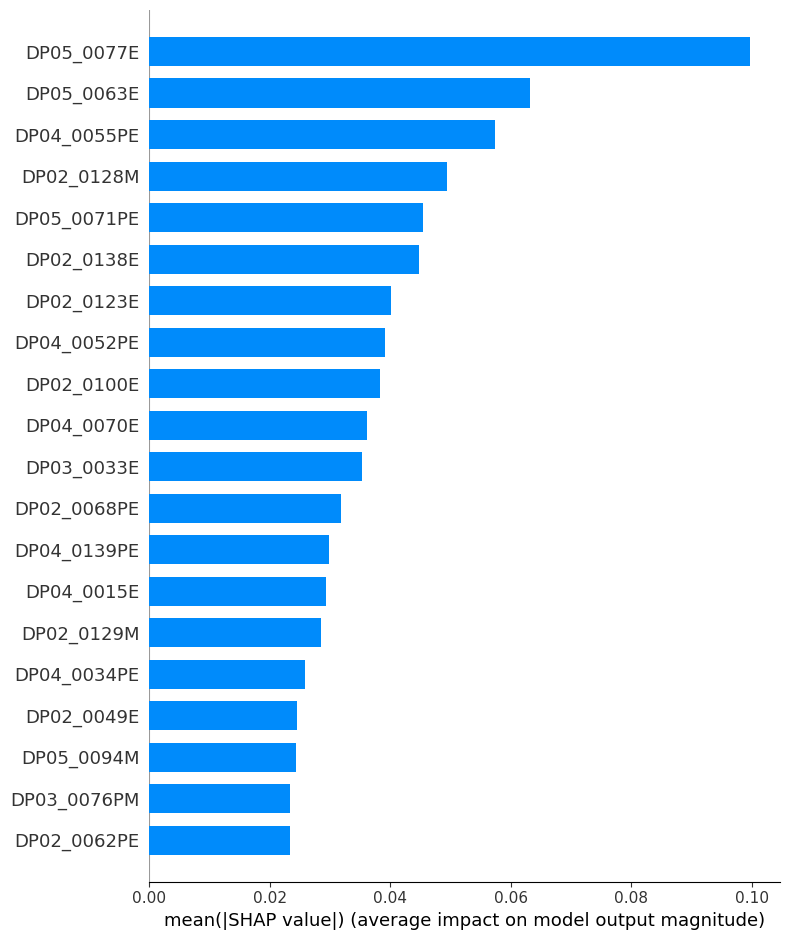

In [33]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="dot")
shap.summary_plot(shap_values, X_test, plot_type="bar")

## 11. Partial Dependence

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import numpy as np

booster = xgb.get_booster()
importance_dict = booster.get_score(importance_type='gain')

# Sort features by importance
sorted_feats = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
top_features = [feat for feat, score in sorted_feats[:3]]

print("Top 3 features for PDP:")
for f in top_features:
    print(" •", f)

fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    xgb,
    X_train,
    features=top_features,
    kind="average",
    ax=ax
)

plt.suptitle("Partial Dependence Plots — XGBoost Cox Model", fontsize=14)
plt.tight_layout()
plt.show()

Top 3 features for PDP:
 • DP05_0063E
 • DP05_0062PM
 • DP03_0037PM
